In [474]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [475]:
df=pd.read_csv("files/co2.csv")
df.head()


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [476]:
df.shape

(7385, 12)

In [477]:
df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')

In [478]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [479]:
df.isnull().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

In [480]:
numeric_df=df.select_dtypes(include=['int64','float64'])
numeric_columns=numeric_df.columns
print(numeric_columns)

Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')


In [481]:
corr_matrix=numeric_df.corr()
targets=['CO2 Emissions(g/km)']
corr_matrix[targets]

,CO2 Emissions(g/km)
Engine Size(L),0.851145
Cylinders,0.832644
Fuel Consumption City (L/100 km),0.919592
Fuel Consumption Hwy (L/100 km),0.883536
Fuel Consumption Comb (L/100 km),0.918052
Fuel Consumption Comb (mpg),-0.907426
CO2 Emissions(g/km),1.000000


In [482]:
exclude_features=['Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)','Fuel Consumption Comb (mpg)','Cylinders']

In [483]:
for target in targets:
    final_features = [
        col for col in numeric_columns
        if col not in exclude_features and col != target]
    print(f"Target: {target}")
    print(final_features)

Target: CO2 Emissions(g/km)
['Engine Size(L)', 'Fuel Consumption Comb (L/100 km)']


In [484]:
#Correlation matrix of final features 
final_corr_matrix=df[final_features+targets].corr()
print(final_corr_matrix)

                                  Engine Size(L)  \
Engine Size(L)                          1.000000   
Fuel Consumption Comb (L/100 km)        0.817060   
CO2 Emissions(g/km)                     0.851145   

                                  Fuel Consumption Comb (L/100 km)  \
Engine Size(L)                                            0.817060   
Fuel Consumption Comb (L/100 km)                          1.000000   
CO2 Emissions(g/km)                                       0.918052   

                                  CO2 Emissions(g/km)  
Engine Size(L)                               0.851145  
Fuel Consumption Comb (L/100 km)             0.918052  
CO2 Emissions(g/km)                          1.000000  


<Axes: >

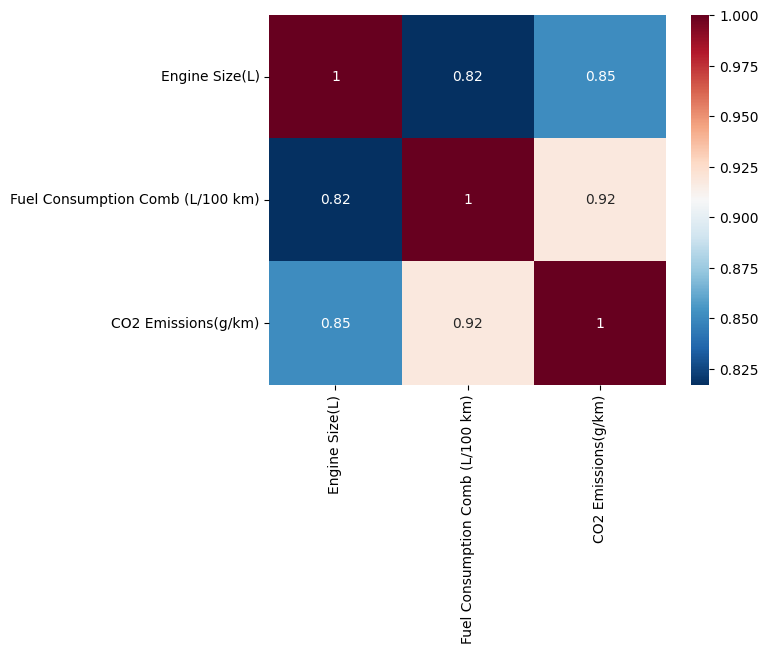

In [485]:
sns.heatmap(final_corr_matrix,annot=True,cmap="RdBu_r")


In [486]:
#to check for feature scaling:
df[final_features+targets].describe()
#we need to scale them



,Engine Size(L),Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000
mean,3.160068,10.975071,250.584699
std,1.354170,2.892506,58.512679
min,0.900000,4.100000,96.000000
25%,2.000000,8.900000,208.000000
50%,3.000000,10.600000,246.000000
75%,3.700000,12.600000,288.000000
max,8.400000,26.100000,522.000000


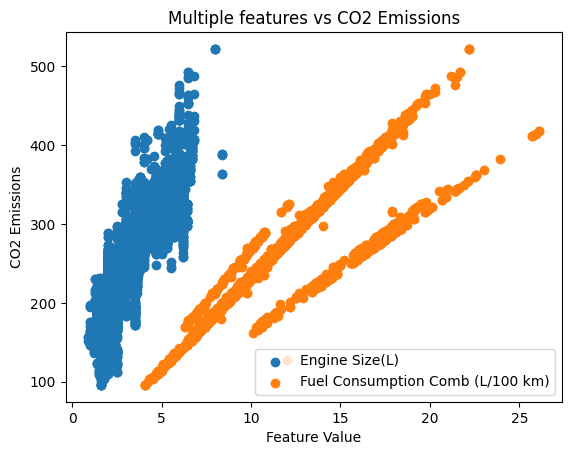

In [487]:

features = ['Engine Size', 'Fuel Consumption Comb']
target = 'CO2 Emissions(g/km)'


for feature in final_features:
    plt.scatter(df[feature], df[target], label=feature)

plt.xlabel('Feature Value')
plt.ylabel('CO2 Emissions')
plt.title('Multiple features vs CO2 Emissions')
plt.legend()
plt.show()


In [488]:
#There ar eoutliers, so we choose robust scaling 

In [489]:
#Robust scaling: 
scale_df=df[final_features].copy()
for col in scale_df.columns:
    median=scale_df[col].median()
    Q1=scale_df[col].quantile(0.25)
    Q3=scale_df[col].quantile(0.75)
    IQR=Q3-Q1

    scale_df[col]=(scale_df[col]-median)/IQR

In [490]:
#Robust scaling y values too
scale_target_df=df[[target]].copy()
median=scale_target_df.median()
Q1=scale_target_df.quantile(0.25)
Q3=scale_target_df.quantile(0.75)
IQR=Q3-Q1
scale_target_df=(scale_target_df-median)/IQR

In [491]:
#assign y and x values
x=scale_df.values
y=scale_target_df.values.ravel()

In [492]:
#split into train and test set:
# (70% train, 30% test)
np.random.seed(42)
indices = np.arange(len(x))
np.random.shuffle(indices)

split = int(0.7 * len(x))
train_idx = indices[:split]
test_idx = indices[split:]

X_train = x[train_idx]
X_test = x[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

In [493]:
#Linear-regression model
class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, iterations=2000,decay=0.001,tol=1e-6,patience=300):
        self.lr0 = learning_rate
        self.lr=learning_rate
        self.decay=decay
        self.iterations = iterations
        self.costs = []
        self.wait=0
        self.tol=tol
        self.patience=patience

    def fit(self, x, y):
        #Initialize paramters:
        self.m, self.n = x.shape
        self.w = np.zeros(self.n)
        self.b = 0

        for i in range(self.iterations):
            self.lr=self.lr0/(1+self.decay*i)
            y_pred = self.predict(x)

            dw = (2/self.m) * x.T.dot(y_pred - y) #Changing the weight, partial derivative of j wrt w
            db = (2/self.m) * np.sum(y_pred - y) #partial derivative of J wrt b

            self.w -= self.lr * dw 
            self.b -= self.lr * db

            cost = np.mean((y - y_pred) ** 2)
            self.costs.append(cost)

            #early stopping check:
            if i >0:
                if abs(self.costs[-1]-self.costs[-2])<self.tol:
                    self.wait+=1
                else:
                    self.wait=0

                if self.wait>=self.patience:
                    print(f"Early stopping at iteration{i}")
                    break

    def predict(self, x):
        return x.dot(self.w) + self.b


In [494]:
model = LinearRegressionGD(learning_rate=0.01,iterations=20000,decay=0.001,tol=1e-6,patience=500)
model.fit(X_train, y_train)

print("Weights:", model.w)
print("Bias:", model.b)


Early stopping at iteration1335
Weights: [0.30653103 0.58988042]
Bias: -0.033544994270776354


In [495]:
y_pred= model.predict(X_test)

#unscaling y values:

median_y = df[target].median()
Q1_y = df[target].quantile(0.25)
Q3_y = df[target].quantile(0.75)
IQR_y = Q3_y - Q1_y

# Unscale predicted and actual y values
y_pred_real = y_pred * IQR_y + median_y
y_test_real = y_test.ravel() * IQR_y + median_y  # make sure y_test is 1D

# Compute RMSE in original units
rmse_real = np.sqrt(np.mean((y_test_real - y_pred_real) ** 2))

# Compute R² in original units
ss_total = np.sum((y_test_real - np.mean(y_test_real)) ** 2)
ss_res = np.sum((y_test_real - y_pred_real) ** 2)
r2_real = 1 - ss_res / ss_total

# print("\nRMSE (original units):", rmse_real)
# rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
# ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
# ss_res = np.sum((y_test - y_pred) ** 2)
# r2 = 1 - ss_res / ss_total

print("\nRMSE:", rmse_real)
print("R-squared:", r2_real)


RMSE: 20.229929508598207
R-squared: 0.8853090099046498


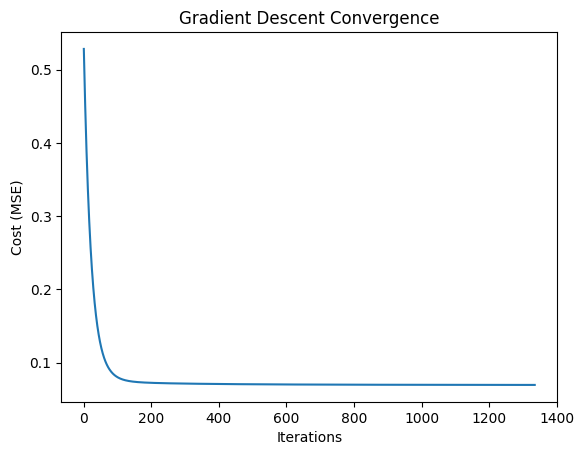

In [496]:
plt.plot(model.costs)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()


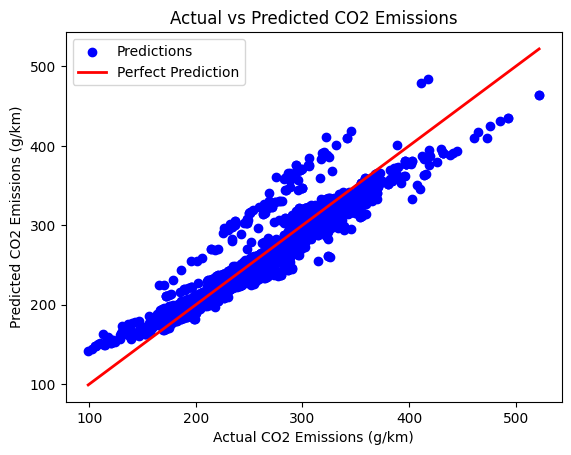

In [501]:

# Scatter plot of actual vs predicted #You keep y unscaled 
plt.scatter(y_test_real, y_pred_real, color='blue', label='Predictions')

# Perfect prediction line
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual CO2 Emissions (g/km)")
plt.ylabel("Predicted CO2 Emissions (g/km)")
plt.title("Actual vs Predicted CO2 Emissions")
plt.legend()

In [498]:
#How to improve: 
#add feature relationship interaction like engine sixe x fuel consumption 
#polynomial regression



In [502]:
rmse_train = np.sqrt(np.mean((y_train - y_pred_real)**2))
rmse_test  = np.sqrt(np.mean((y_test - y_test_real)**2))

# R²
r2_train = 1 - np.sum((y_train - y_pred_real)**2)/np.sum((y_train - np.mean(y_train))**2)
r2_test  = 1 - np.sum((y_test - y_test_real)**2)/np.sum((y_test - np.mean(y_test))**2)

print("Training RMSE:", rmse_train, "R²:", r2_train)
print("Validation RMSE:", rmse_test, "R²:", r2_test)

ValueError: operands could not be broadcast together with shapes (5169,) (2216,) 